# Abrikosov-pseudofermion (RVB spinon) mean-field theory for Heisenberg models

`SpinonHamiltonian` (`pyqula.spinon`) treats a pure spin-$\tfrac12$ Heisenberg model
$H=J\sum_{\langle ij\rangle}\vec S_i\cdot\vec S_j$ on its own terms via the Abrikosov-pseudofermion
representation $\vec S_i=\tfrac12 f_i^\dagger\vec\sigma f_i$ (Savary & Balents, arXiv:1601.03742,
Sec. 4): each spin becomes an auxiliary ("spinon") fermion under the hard local constraint
$f_i^\dagger f_i=1$, exactly one fermion per site, enforced individually via a per-site Lagrange
multiplier co-converged in the same SCF loop as the RVB bond order parameter
$\chi_{ij}=\langle f_i^\dagger f_j\rangle$. An external field couples exactly (not via any
mean-field decoupling, since $\vec S_i$ is already bilinear in $f$) and competes with the exchange,
saturating the induced moment once it dominates $J$.

Converged <n_i> per site (target 1.0): [1.]


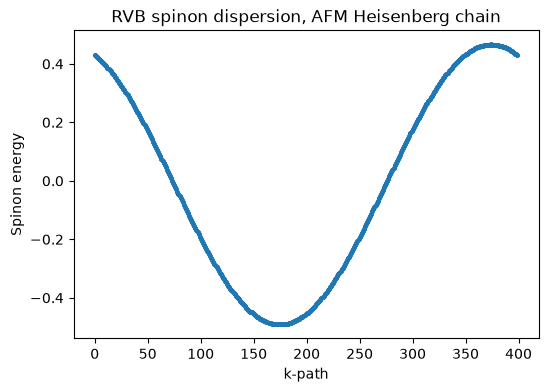

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula.spinon import SpinonHamiltonian

np.random.seed(0)
g = geometry.chain()
h = SpinonHamiltonian(g) # zero bare hopping: a pure spin model
h2 = h.get_mean_field_hamiltonian(J1=1.0,nk=24,mix=0.3,maxerror=1e-5,maxite=2000)

print("Converged <n_i> per site (target 1.0):",h2.local_occupation)
(k,e) = h2.get_bands()

plt.figure(figsize=(6,4))
plt.scatter(k,e,s=6)
plt.xlabel("k-path") ; plt.ylabel("Spinon energy")
plt.title("RVB spinon dispersion, AFM Heisenberg chain")
plt.show()

An external Zeeman field, applied before `get_mean_field_hamiltonian`, induces a magnetization that grows with field while the local constraint stays exactly satisfied:

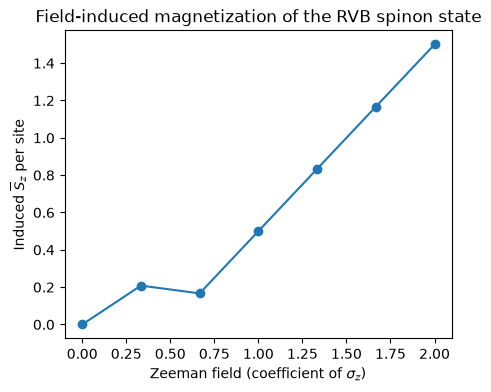

In [2]:
fields = np.linspace(0.0,2.0,7)
done_fields,magnetizations = [],[]
for b in fields:
    np.random.seed(0)
    hb = SpinonHamiltonian(g)
    hb.add_zeeman([0.,0.,b])
    h2b = hb.get_mean_field_hamiltonian(J1=1.0,nk=24,mix=0.3,maxerror=1e-6,maxite=2000)
    if h2b is None: continue # SCF can fail to converge right at a metamagnetic jump
    done_fields.append(b)
    magnetizations.append(h2b.get_magnetization()[0][2])

plt.figure(figsize=(5,4))
plt.plot(done_fields,magnetizations,marker="o")
plt.xlabel("Zeeman field (coefficient of $\sigma_z$)")
plt.ylabel("Induced $\overline{S}_z$ per site")
plt.title("Field-induced magnetization of the RVB spinon state")
plt.show()